In [1]:
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

class CIFAR10DataLoader:
    def __init__(self, batch_size=128):
        self.batch_size = batch_size
        self.transform_train = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ])
        self.transform_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ])

    def get_loaders(self):
        trainset = torchvision.datasets.CIFAR10(
            root='./data', train=True, download=True, transform=self.transform_train)
        testset = torchvision.datasets.CIFAR10(
            root='./data', train=False, download=True, transform=self.transform_test)
        
        trainloader = DataLoader(
            trainset, batch_size=self.batch_size, shuffle=True, num_workers=2)
        testloader = DataLoader(
            testset, batch_size=self.batch_size, shuffle=False, num_workers=2)
        return trainloader, testloader

class Trainer:
    def __init__(self, model, train_loader, test_loader, device, optimizer_type='sgd', 
                 epochs=100, lr=0.1, weight_decay=5e-4):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.device = device
        self.epochs = epochs
        self.criterion = nn.CrossEntropyLoss()
        if optimizer_type.lower() == 'adam':
            self.optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        else:
            self.optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
        
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=30, gamma=0.1)
        self.best_acc = 0.0
        self.train_acc_history = []
        self.test_acc_history = []
        self.train_loss_history = []
        self.test_loss_history = []
        self.config = {
            'optimizer': optimizer_type,
            'lr': lr,
            'weight_decay': weight_decay
        }

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in self.train_loader:
            inputs, labels = inputs.to(self.device), labels.to(self.device)
            self.optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        return total_loss/len(self.train_loader), 100.*correct/total

    def evaluate(self):
        self.model.eval()
        total_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in self.test_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                
                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        return total_loss/len(self.test_loader), 100.*correct/total

    def train(self):
        print(f"Training with config: {self.config}")
        for epoch in range(self.epochs):
            train_loss, train_acc = self.train_epoch()
            test_loss, test_acc = self.evaluate()
            self.scheduler.step()
            
            self.train_acc_history.append(train_acc)
            self.test_acc_history.append(test_acc)
            self.train_loss_history.append(train_loss)
            self.test_loss_history.append(test_loss)
            
            print(f"Epoch {epoch+1}/{self.epochs}")
            print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
            print(f"Test Loss: {test_loss:.4f} | Acc: {test_acc:.2f}%")
            
            if test_acc > self.best_acc:
                self.best_acc = test_acc
                torch.save(self.model.state_dict(), f"best_model_{self.config['optimizer']}_lr{self.config['lr']}.pth")
        
        print(f"Best Test Accuracy: {self.best_acc:.2f}%")
        self.save_results()

    def save_results(self):
        import pandas as pd
        results = {
            'epoch': list(range(1, self.epochs+1)),
            'train_acc': self.train_acc_history,
            'test_acc': self.test_acc_history,
            'train_loss': self.train_loss_history,
            'test_loss': self.test_loss_history
        }
        df = pd.DataFrame(results)
        config_str = f"{self.config['optimizer']}_lr{self.config['lr']}_wd{self.config['weight_decay']}"
        filename = f"training_results_{config_str}.csv"
        df.to_csv(filename, index=False)
        print(f"Results saved to {filename}")

In [2]:
def run_experiments():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    batch_size = 128
    
    lr_list = [0.1, 0.01, 0.001, 0.0001]
    optimizers = ['sgd', 'adam']
    
    data_loader = CIFAR10DataLoader(batch_size)
    train_loader, test_loader = data_loader.get_loaders()
    
    for optimizer_type in optimizers:
        for lr in lr_list:
            print(f"\n=== Starting experiment: {optimizer_type.upper()} with LR={lr} ===")
            model = ResNet()
            trainer = Trainer(model, train_loader, test_loader, device, 
                            optimizer_type=optimizer_type, lr=lr)
            trainer.train()
            
            plot_learning_curves(trainer, f"{optimizer_type}_lr{lr}")

def plot_learning_curves(trainer, config_str):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(trainer.train_acc_history, label='Train Acc')
    plt.plot(trainer.test_acc_history, label='Test Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title(f'Accuracy Curves\n{config_str}')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(trainer.train_loss_history, label='Train Loss')
    plt.plot(trainer.test_loss_history, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Loss Curves\n{config_str}')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(f"learning_curves_{config_str}.png")
    plt.close()

if __name__ == "__main__":
    run_experiments()

100%|██████████| 170M/170M [00:02<00:00, 64.7MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified

=== Starting experiment: SGD with LR=0.1 ===
Training with config: {'optimizer': 'sgd', 'lr': 0.1, 'weight_decay': 0.0005}
Epoch 1/100
Train Loss: 1.6351 | Acc: 39.26%
Test Loss: 1.2993 | Acc: 53.04%
Epoch 2/100
Train Loss: 1.1381 | Acc: 58.99%
Test Loss: 1.1944 | Acc: 58.15%
Epoch 3/100
Train Loss: 0.8723 | Acc: 68.96%
Test Loss: 0.8703 | Acc: 70.48%
Epoch 4/100
Train Loss: 0.7067 | Acc: 75.40%
Test Loss: 0.8379 | Acc: 71.33%
Epoch 5/100
Train Loss: 0.6111 | Acc: 78.95%
Test Loss: 0.7241 | Acc: 75.89%
Epoch 6/100
Train Loss: 0.5510 | Acc: 81.11%
Test Loss: 0.6753 | Acc: 77.39%
Epoch 7/100
Train Loss: 0.5106 | Acc: 82.55%
Test Loss: 0.8109 | Acc: 75.50%
Epoch 8/100
Train Loss: 0.4850 | Acc: 83.26%
Test Loss: 0.5739 | Acc: 80.86%
Epoch 9/100
Train Loss: 0.4650 | Acc: 84.02%
Test Loss: 0.9028 | Acc: 71.54%
Epoch 10/100
Train Loss: 0.4430 | Acc: 84.86%
Test Loss: 0.5454 | Acc: 81.86%
Epoch 11/100
Tra

In [3]:
import pandas as pd
import glob

def summarize_results():
    files = glob.glob("training_results_*.csv")
    summary = []
    
    for f in files:
        config = f.replace("training_results_", "").replace(".csv", "")
        optimizer, lr, wd = config.split("_")
        lr_value = float(lr.replace("lr", ""))
        wd_value = float(wd.replace("wd", ""))
        
        df = pd.read_csv(f)
        best_test_acc = df['test_acc'].max()
        final_test_acc = df['test_acc'].iloc[-1]
        final_train_acc = df['train_acc'].iloc[-1]
        
        summary.append({
            'Optimizer': optimizer.upper(),
            'Learning Rate': lr_value,
            'Weight Decay': wd_value,
            'Best Test Acc': best_test_acc,
            'Final Test Acc': final_test_acc,
            'Final Train Acc': final_train_acc
        })
    
    summary_df = pd.DataFrame(summary)
    summary_df.to_csv("experiment_summary.csv", index=False)
    print(summary_df.sort_values(by='Best Test Acc', ascending=False))
    return summary_df

summary_df = summarize_results()

  Optimizer  Learning Rate  Weight Decay  Best Test Acc  Final Test Acc  \
4       SGD         0.1000        0.0005          94.38           94.32   
3       SGD         0.0100        0.0005          93.25           93.11   
7      ADAM         0.0010        0.0005          92.16           92.12   
2      ADAM         0.0001        0.0005          91.34           91.19   
1       SGD         0.0010        0.0005          89.67           89.46   
6      ADAM         0.0100        0.0005          83.64           83.53   
5      ADAM         0.1000        0.0005          76.94           76.84   
0       SGD         0.0001        0.0005          72.81           72.61   

   Final Train Acc  
4           99.984  
3           99.866  
7           99.728  
2           99.772  
1           97.094  
6           86.034  
5           77.610  
0           74.378  


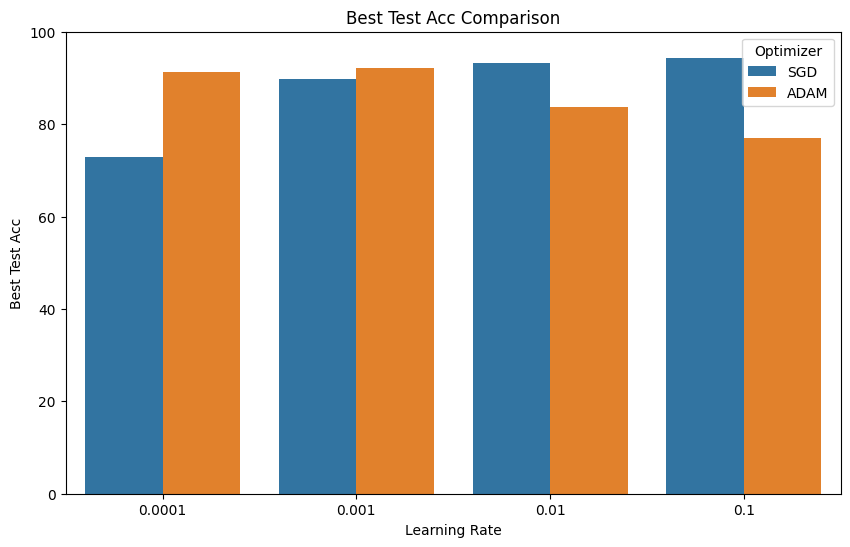

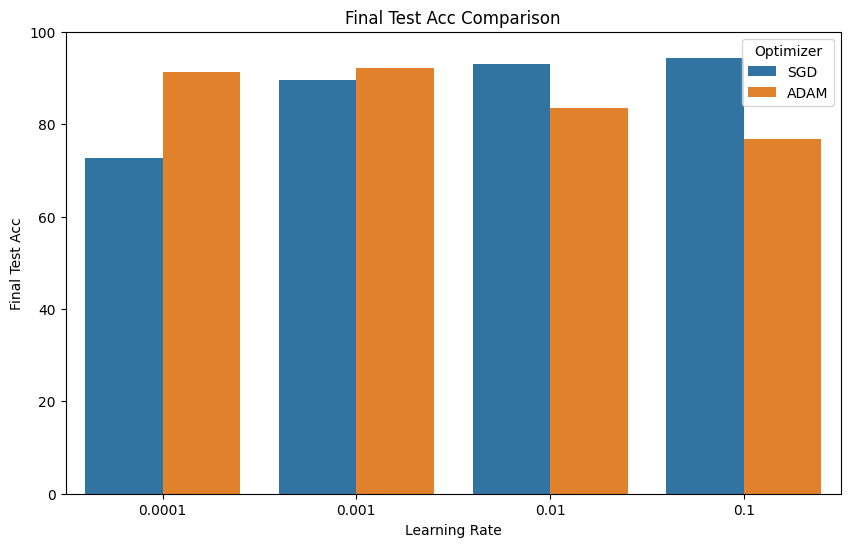

In [4]:
def visualize_comparison(summary_df):
    for metric in ['Best Test Acc', 'Final Test Acc']:
        plt.figure(figsize=(10, 6))
        sns.barplot(data=summary_df, x='Learning Rate', y=metric, hue='Optimizer')
        plt.title(f'{metric} Comparison')
        plt.ylim(0, 100)
        plt.savefig(f"{metric.lower().replace(' ', '_')}_comparison.png")
        plt.show()

visualize_comparison(summary_df)